In [0]:
df_spark = spark.table("churndata")
df_spark.show(5)



+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|  balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|   15634602|         619| France|Female| 42|     2|      0.0|              1|          1|            1|       101348.88|    1|
|   15647311|         608|  Spain|Female| 41|     1| 83807.86|              1|          0|            1|       112542.58|    0|
|   15619304|         502| France|Female| 42|     8| 159660.8|              3|          1|            0|       113931.57|    1|
|   15701354|         699| France|Female| 39|     1|      0.0|              2|          0|            0|        93826.63|    0|
|   15737888|         850|  Spain|Female| 43|     2|125510.82|              1|          1|            1|

In [0]:
df = df_spark.toPandas()
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [0]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_nu


Procentowy rozkład zmiennej churn:
 churn
0    79.63
1    20.37
Name: proportion, dtype: float64


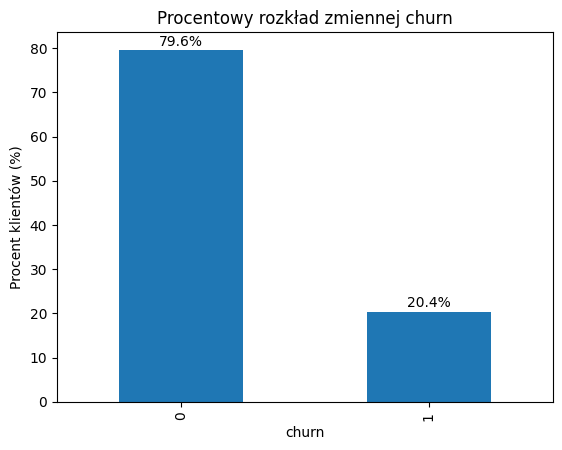


=== Statystyki opisowe dla zmiennych liczbowych ===
        customer_id  credit_score  ...  estimated_salary         churn
count  1.000000e+04  10000.000000  ...      10000.000000  10000.000000
mean   1.569094e+07    650.528800  ...     100090.239881      0.203700
std    7.193619e+04     96.653299  ...      57510.492818      0.402769
min    1.556570e+07    350.000000  ...         11.580000      0.000000
25%    1.562853e+07    584.000000  ...      51002.110000      0.000000
50%    1.569074e+07    652.000000  ...     100193.915000      0.000000
75%    1.575323e+07    718.000000  ...     149388.247500      0.000000
max    1.581569e+07    850.000000  ...     199992.480000      1.000000

[8 rows x 10 columns]

=== Statystyki opisowe dla zmiennych kategorycznych ===
       country gender
count    10000  10000
unique       3      2
top     France   Male
freq      5014   5457

Pierwsze 5 wierszy po przygotowaniu danych:
   customer_id  credit_score  gender  ...  churn  country_Germany  countr

In [0]:

import matplotlib.pyplot as plt
import pandas as pd


# Procentowy rozkład zmiennej churn
percentages = df["churn"].value_counts(normalize=True) * 100
print("\nProcentowy rozkład zmiennej churn:\n", percentages)

# Wykres słupkowy
percentages.plot(kind="bar")
plt.title("Procentowy rozkład zmiennej churn")
plt.xlabel("churn")
plt.ylabel("Procent klientów (%)")
for i, value in enumerate(percentages):
    plt.text(i, value + 1, f"{value:.1f}%", ha='center')
plt.show()

# Statystyki opisowe dla zmiennych liczbowych
print("\n=== Statystyki opisowe dla zmiennych liczbowych ===")
print(df.describe())

# Statystyki opisowe dla zmiennych kategorycznych
print("\n=== Statystyki opisowe dla zmiennych kategorycznych ===")
print(df.describe(include=['object', 'category']))

# --- Przygotowanie danych do modelu ---
# Binaryzacja zmiennej gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Kodowanie zmiennej country (One-Hot Encoding, drop_first=True)
df = pd.get_dummies(df, columns=['country'], drop_first=True, dtype=int)

# Sprawdzenie efektu
print("\nPierwsze 5 wierszy po przygotowaniu danych:")
print(df.head())


In [0]:
from sklearn.preprocessing import StandardScaler


num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('churn') 

# Skalowanie
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Pierwsze 5 wierszy po skalowaniu zmiennych liczbowych:")
print(df.head())


Pierwsze 5 wierszy po skalowaniu zmiennych liczbowych:
   customer_id  credit_score    gender  ...  churn  country_Germany  country_Spain
0    -0.783213     -0.326221 -1.095988  ...      1        -0.578736      -0.573809
1    -0.606534     -0.440036 -1.095988  ...      0        -0.578736       1.742740
2    -0.995885     -1.536794 -1.095988  ...      1        -0.578736      -0.573809
3     0.144767      0.501521 -1.095988  ...      0        -0.578736      -0.573809
4     0.652659      2.063884 -1.095988  ...      0        -0.578736       1.742740

[5 rows x 13 columns]


In [0]:
# BUDOWA SIECI NEURONOWEJ

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report


# Przygotowanie danych
y = df['churn']
X = df.drop('churn', axis=1)

# Skalowanie zmiennych liczbowych
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definicja modelu MLP
mlp = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu', solver='adam', alpha = 0.001, max_iter=200, random_state=42)

# Trenowanie modelu
mlp.fit(X_train, y_train)

# Ewaluacja
accuracy = mlp.score(X_test, y_test)
print(f"Dokładność na zbiorze testowym: {accuracy:.2f}")

# Predykcje na zbiorze testowym
y_pred = mlp.predict(X_test)

# Obliczenie recall
recall = recall_score(y_test, y_pred)
print(f"Recall na zbiorze testowym: {recall:.2f}")



Dokładność na zbiorze testowym: 0.86
Recall na zbiorze testowym: 0.50


/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [0]:

# Predykcje na zbiorze testowym
y_pred = mlp.predict(X_test)

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Macierz konfuzji
cm = confusion_matrix(y_test, y_pred)
print("Macierz konfuzji:\n", cm)

# Pełny raport klasyfikacji
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))


Recall: 0.50
Precision: 0.72
F1-score: 0.59
Macierz konfuzji:
 [[1512   81]
 [ 202  205]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.72      0.50      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [0]:

# WYBÓR OPTYMALNEGO PROGU DECYZYJNEGO

import numpy as np
from sklearn.metrics import f1_score

# Prawdopodobieństwa przewidywane przez model
y_proba = mlp.predict_proba(X_test)[:, 1]

# Definicja zakresu progów
thresholds = np.arange(0, 1.01, 0.01)  # od 0 do 1 z krokiem 0.01

best_f1 = 0
best_threshold = 0

# Iteracja po wszystkich progach
for t in thresholds:  
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Najlepszy threshold maksymalizujący F1-score: {best_threshold:.2f}")
print(f"Maksymalne F1-score: {best_f1:.2f}")


Najlepszy threshold maksymalizujący F1-score: 0.43
Maksymalne F1-score: 0.62


In [0]:
# WARTOŚĆ METRYK PRZY OPTYMALNYM PROGU DECYZYJNYM

# Predykcja prawdopodobieństw
y_proba = mlp.predict_proba(X_test)[:,1]

# Ustalamy nowy próg
threshold = 0.43

# Zamiana prawdopodobieństw na klasy z tym progiem
y_pred_threshold = (y_proba >= threshold).astype(int)

# Ewaluacja
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

print(f"Precision: {precision_score(y_test, y_pred_threshold):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_threshold):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_threshold):.2f}")
print("\nMacierz pomyłek:\n", confusion_matrix(y_test, y_pred_threshold))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_threshold))



Precision: 0.68
Recall: 0.57
F1-score: 0.62

Macierz pomyłek:
 [[1483  110]
 [ 173  234]]

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91      1593
           1       0.68      0.57      0.62       407

    accuracy                           0.86      2000
   macro avg       0.79      0.75      0.77      2000
weighted avg       0.85      0.86      0.85      2000



Threshold,Precision,Recall,F1-score
0.1,0.35470527404343327,0.8427518427518428,0.4992721979621543
0.15000000000000002,0.4070221066319896,0.769041769041769,0.532312925170068
0.20000000000000004,0.463452566096423,0.7321867321867321,0.5676190476190476
0.25000000000000006,0.52,0.7027027027027027,0.5977011494252874
0.30000000000000004,0.5601659751037344,0.6633906633906634,0.6074240719910011
0.3500000000000001,0.6097560975609756,0.6142506142506142,0.6119951040391677
0.40000000000000013,0.6512261580381471,0.5872235872235873,0.6175710594315246
0.45000000000000007,0.6990595611285266,0.547911547911548,0.6143250688705234
0.5000000000000001,0.7167832167832168,0.5036855036855037,0.5916305916305916
0.5500000000000002,0.751937984496124,0.47665847665847666,0.5834586466165413


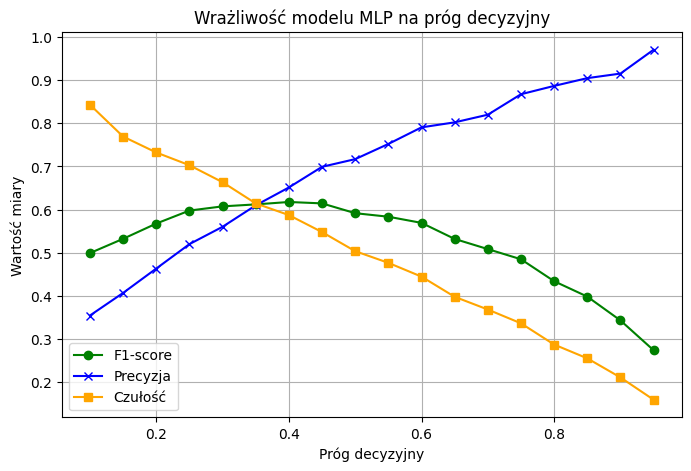

Optymalny próg dla F1-score: 0.40, F1-score: 0.618


In [0]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# Predykcja prawdopodobieństw 
y_prob = mlp.predict_proba(X_test)[:, 1]

# Testujemy różne progi 
thresholds = np.arange(0.1, 1, 0.05)
f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))

# Znalezienie optymalnego progu F1 
max_f1 = max(f1_scores)
opt_idx = f1_scores.index(max_f1)
opt_threshold = thresholds[opt_idx]

# Tabela wyników 
df_threshold = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'F1-score': f1_scores
})
display(df_threshold)

# Wykres 
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o', label='F1-score', color='green')
plt.plot(thresholds, precisions, marker='x', label='Precyzja', color='blue')
plt.plot(thresholds, recalls, marker='s', label='Czułość', color='orange')


plt.xlabel('Próg decyzyjny')
plt.ylabel('Wartość miary')
plt.title('Wrażliwość modelu MLP na próg decyzyjny')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optymalny próg dla F1-score: {opt_threshold:.2f}, F1-score: {max_f1:.3f}")



Wrażliwość cech (spadek F1 przy permutacji):
age: 0.2193
products_number: 0.2170
country_Germany: 0.0647
active_member: 0.0644
balance: 0.0572
credit_card: 0.0110
credit_score: 0.0108
tenure: 0.0096
country_Spain: 0.0087
gender: 0.0070
estimated_salary: -0.0018
customer_id: -0.0069


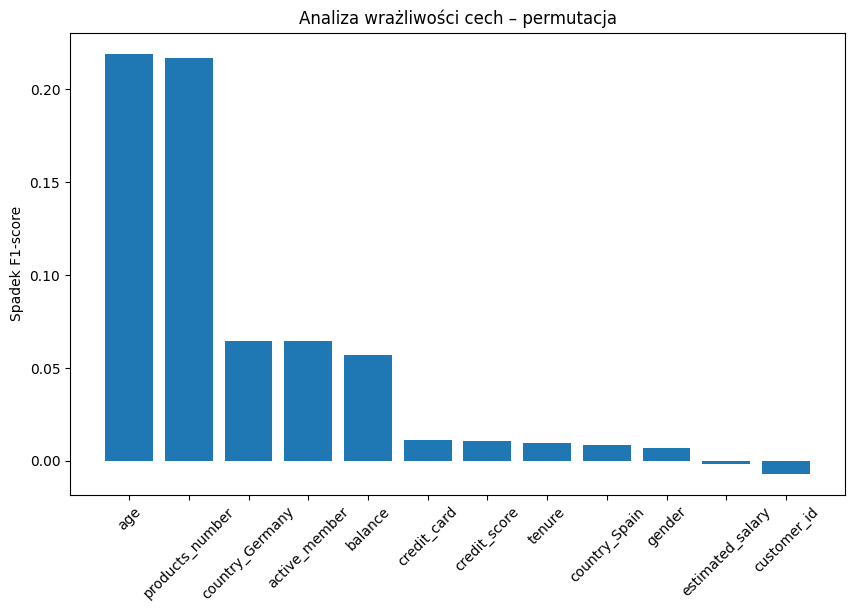

In [0]:
# ANALIZA WRAZLIWOSCI - CECHY WEJSCIOWE

from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# Bazowy F1
y_pred_base = mlp.predict(X_test)
baseline_f1 = f1_score(y_test, y_pred_base)

# Słownik do przechowywania spadku F1
feature_sensitivity = {}

# Permutacja każdej cechy
for col in X_test.columns:
    X_test_perm = X_test.copy()
    X_test_perm[col] = np.random.permutation(X_test_perm[col])
    y_pred_perm = mlp.predict(X_test_perm)
    f1_perm = f1_score(y_test, y_pred_perm)
    feature_sensitivity[col] = baseline_f1 - f1_perm  # spadek F1

# Sortowanie po największym spadku
feature_sensitivity = dict(sorted(feature_sensitivity.items(), key=lambda x: x[1], reverse=True))

# Wyświetlenie wyników
print("Wrażliwość cech (spadek F1 przy permutacji):")
for feature, drop in feature_sensitivity.items():
    print(f"{feature}: {drop:.4f}")

# Wykres słupkowy
plt.figure(figsize=(10,6))
plt.bar(feature_sensitivity.keys(), feature_sensitivity.values())
plt.xticks(rotation=45)
plt.ylabel('Spadek F1-score')
plt.title('Analiza wrażliwości cech – permutacja')
plt.show()


F1-score dla różnych liczby epok:
50 epok: F1-score = 0.6132
100 epok: F1-score = 0.6182
200 epok: F1-score = 0.6232
300 epok: F1-score = 0.5932


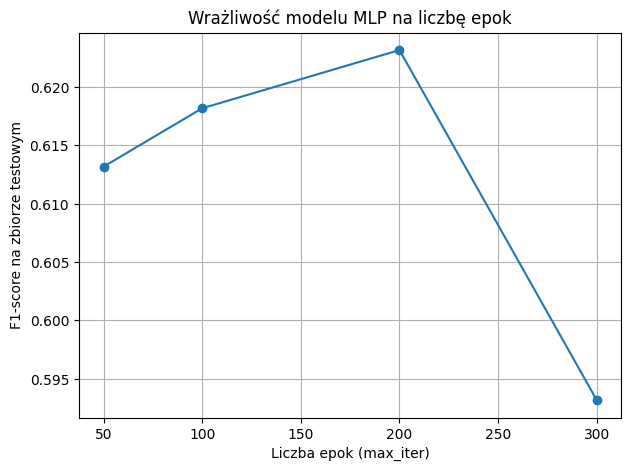

In [0]:
# ANALIZA WRAZLIWOSCI - ARCHITEKTURA SIECI (LICZBA EPOK)

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

# Zakres liczby epok do testowania
epoki = [50, 100, 200, 300]
f1_scores_epochs = []

# Pętla po różnych liczbach epok
for max_iter in epoki:
    mlp_tmp = MLPClassifier(hidden_layer_sizes=(32,16),
                            activation='relu',
                            solver='adam',
                            alpha=0.001,
                            max_iter=max_iter,
                            random_state=42)
    mlp_tmp.fit(X_train, y_train)
    
    # Predykcja z optymalnym progiem 0.43
    y_prob_tmp = mlp_tmp.predict_proba(X_test)[:,1]
    y_pred_tmp = (y_prob_tmp >= 0.43).astype(int)
    
    f1_scores_epochs.append(f1_score(y_test, y_pred_tmp))

# Wyświetlenie wyników w tabeli
print("F1-score dla różnych liczby epok:")
for e, f1 in zip(epoki, f1_scores_epochs):
    print(f"{e} epok: F1-score = {f1:.4f}")

# Wykres F1-score vs liczba epok
plt.figure(figsize=(7,5))
plt.plot(epoki, f1_scores_epochs, marker='o')
plt.xlabel('Liczba epok (max_iter)')
plt.ylabel('F1-score na zbiorze testowym')
plt.title('Wrażliwość modelu MLP na liczbę epok')
plt.grid(True)
plt.show()



In [0]:
# ANALIZA WRAZLIWOSCI - ARCHITEKTURA SIECI (WARSTWY UKRYTE)

architektury = [(32,), (16,8), (32,16), (64,32), (32,16,8)]
f1_scores_arch = []

for arch in architektury:
    mlp_tmp = MLPClassifier(hidden_layer_sizes=arch,
                            activation='relu',
                            solver='adam',
                            alpha=0.001,
                            max_iter=200,
                            random_state=42)
    mlp_tmp.fit(X_train, y_train)
    y_pred_tmp = (mlp_tmp.predict_proba(X_test)[:,1] >= 0.43).astype(int)
    f1_scores_arch.append(f1_score(y_test, y_pred_tmp))

for arch, f1 in zip(architektury, f1_scores_arch):
    print(f"Architektura {arch}: F1 = {f1:.4f}")


/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Architektura (32,): F1 = 0.6133
Architektura (16, 8): F1 = 0.6207
Architektura (32, 16): F1 = 0.6232
Architektura (64, 32): F1 = 0.5498
Architektura (32, 16, 8): F1 = 0.5975


/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


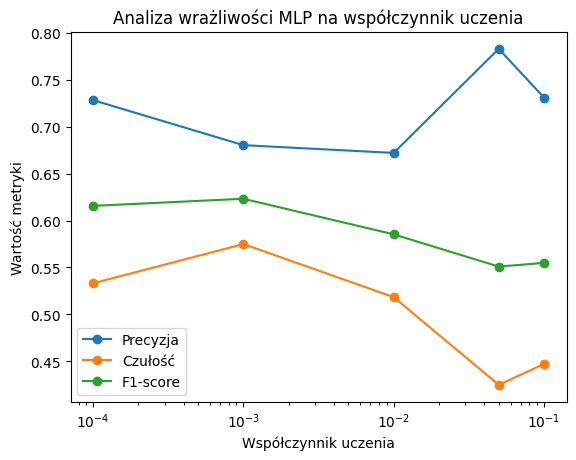

In [0]:
# ANALIZA WRAZLIWOŚCI - LEARNING RATE

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Wektor learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1]
threshold = 0.43

precision_list = []
recall_list = []
f1_list = []

for lr in learning_rates:
    mlp = MLPClassifier(
        hidden_layer_sizes=(32,16),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        alpha=0.001,
        max_iter=200,
        random_state=42
    )
    
    mlp.fit(X_train, y_train)
    
    y_proba = mlp.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

plt.figure()
plt.plot(learning_rates, precision_list, marker='o', label='Precyzja')
plt.plot(learning_rates, recall_list, marker='o', label='Czułość')
plt.plot(learning_rates, f1_list, marker='o', label='F1-score')

plt.xscale('log')
plt.xlabel('Współczynnik uczenia')
plt.ylabel('Wartość metryki')
plt.title('Analiza wrażliwości MLP na współczynnik uczenia')
plt.legend()
plt.show()




In [0]:
################### PONIZEJ REGRESJA LOGISTYCZNA ##########################

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|  balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|   15634602|         619| France|Female| 42|     2|      0.0|              1|          1|            1|       101348.88|    1|
|   15647311|         608|  Spain|Female| 41|     1| 83807.86|              1|          0|            1|       112542.58|    0|
|   15619304|         502| France|Female| 42|     8| 159660.8|              3|          1|            0|       113931.57|    1|
|   15701354|         699| France|Female| 39|     1|      0.0|              2|          0|            0|        93826.63|    0|
|   15737888|         850|  Spain|Female| 43|     2|125510.82|              1|          1|            1|

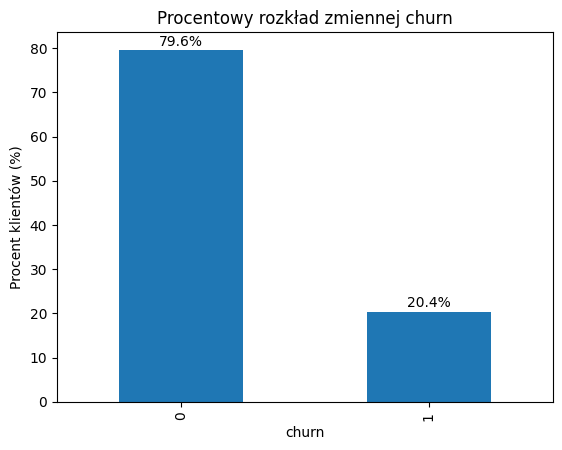

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

df_spark = spark.table("churndata")
df_spark.show(5)
df = df_spark.toPandas()
df.head()

# Sprawdzenie nazw kolumn
print(df.columns)

# Procentowy rozkład zmiennej churn
percentages = df["churn"].value_counts(normalize=True) * 100
print(percentages)

# Wykres słupkowy procentowy
percentages.plot(kind="bar")
plt.title("Procentowy rozkład zmiennej churn")
plt.xlabel("churn")
plt.ylabel("Procent klientów (%)")

for i, value in enumerate(percentages):
    plt.text(i, value + 1, f"{value:.1f}%", ha='center')

plt.show()


In [0]:
# Statystyki opisowe dla zmiennych liczbowych
print("=== Statystyki opisowe dla zmiennych liczbowych ===")
print(df.describe())

# Statystyki opisowe dla zmiennych kategorycznych
print("\n=== Statystyki opisowe dla zmiennych kategorycznych ===")
print(df.describe(include=["object", "category"]))

# Binaryzacja zmiennej gender
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

# Zmienna country – kodowanie one-hot
df = pd.get_dummies(df, columns=["country"], drop_first=True, dtype=int)


=== Statystyki opisowe dla zmiennych liczbowych ===
        customer_id  credit_score  ...  estimated_salary         churn
count  1.000000e+04  10000.000000  ...      10000.000000  10000.000000
mean   1.569094e+07    650.528800  ...     100090.239881      0.203700
std    7.193619e+04     96.653299  ...      57510.492818      0.402769
min    1.556570e+07    350.000000  ...         11.580000      0.000000
25%    1.562853e+07    584.000000  ...      51002.110000      0.000000
50%    1.569074e+07    652.000000  ...     100193.915000      0.000000
75%    1.575323e+07    718.000000  ...     149388.247500      0.000000
max    1.581569e+07    850.000000  ...     199992.480000      1.000000

[8 rows x 10 columns]

=== Statystyki opisowe dla zmiennych kategorycznych ===
       country gender
count    10000  10000
unique       3      2
top     France   Male
freq      5014   5457


In [0]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)

# Przygotowanie danych 
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# GridSearchCV dla logreg 
param_grid = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}
base_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_ 

# Predykcje i metryki ---
y_proba_lr = best_model.predict_proba(X_test_scaled)[:, 1]
threshold_lr = 0.5
y_pred_lr = (y_proba_lr >= threshold_lr).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# Macierz pomyłek
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

# Raport klasyfikacyjny
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


ROC-AUC: 0.7768184208862174
F1-score: 0.5008726003490401
Recall: 0.7051597051597052
Accuracy: 0.714

Confusion Matrix:
[[1141  452]
 [ 120  287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [0]:
# ANALIZA PROGU DECYZYJNEGO
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.1, 0.95, 20)
precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_thresh))
    recall_list.append(recall_score(y_test, y_pred_thresh))
    f1_list.append(f1_score(y_test, y_pred_thresh))
    


/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/s

In [0]:
threshold_analysis = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})

print("\nTabela analizy wrażliwości względem progu decyzyjnego:")
print(threshold_analysis)



Tabela analizy wrażliwości względem progu decyzyjnego:
    Threshold  Precision    Recall  F1-score
0    0.100000   0.365591  0.835381  0.508601
1    0.144737   0.460389  0.756757  0.572491
2    0.189474   0.529963  0.695332  0.601488
3    0.234211   0.579065  0.638821  0.607477
4    0.278947   0.617801  0.579853  0.598226
5    0.323684   0.648318  0.520885  0.577657
6    0.368421   0.677083  0.479115  0.561151
7    0.413158   0.712644  0.457002  0.556886
8    0.457895   0.751073  0.429975  0.546875
9    0.502632   0.767442  0.405405  0.530547
10   0.547368   0.780105  0.366093  0.498328
11   0.592105   0.813253  0.331695  0.471204
12   0.636842   0.835616  0.299754  0.441230
13   0.681579   0.847826  0.287469  0.429358
14   0.726316   0.856000  0.262899  0.402256
15   0.771053   0.853448  0.243243  0.378585
16   0.815789   0.000000  0.000000  0.000000
17   0.860526   0.000000  0.000000  0.000000
18   0.905263   0.000000  0.000000  0.000000
19   0.950000   0.000000  0.000000  0.000000


Tabela analizy wrażliwości względem progu decyzyjnego:
    Threshold  Precision  Recall  F1-score
0       0.100      0.366   0.835     0.509
1       0.145      0.460   0.757     0.572
2       0.189      0.530   0.695     0.601
3       0.234      0.579   0.639     0.607
4       0.279      0.618   0.580     0.598
5       0.324      0.648   0.521     0.578
6       0.368      0.677   0.479     0.561
7       0.413      0.713   0.457     0.557
8       0.458      0.751   0.430     0.547
9       0.503      0.767   0.405     0.531
10      0.547      0.780   0.366     0.498
11      0.592      0.813   0.332     0.471
12      0.637      0.836   0.300     0.441
13      0.682      0.848   0.287     0.429
14      0.726      0.856   0.263     0.402
15      0.771      0.853   0.243     0.379
16      0.816      0.000   0.000     0.000
17      0.861      0.000   0.000     0.000
18      0.905      0.000   0.000     0.000
19      0.950      0.000   0.000     0.000


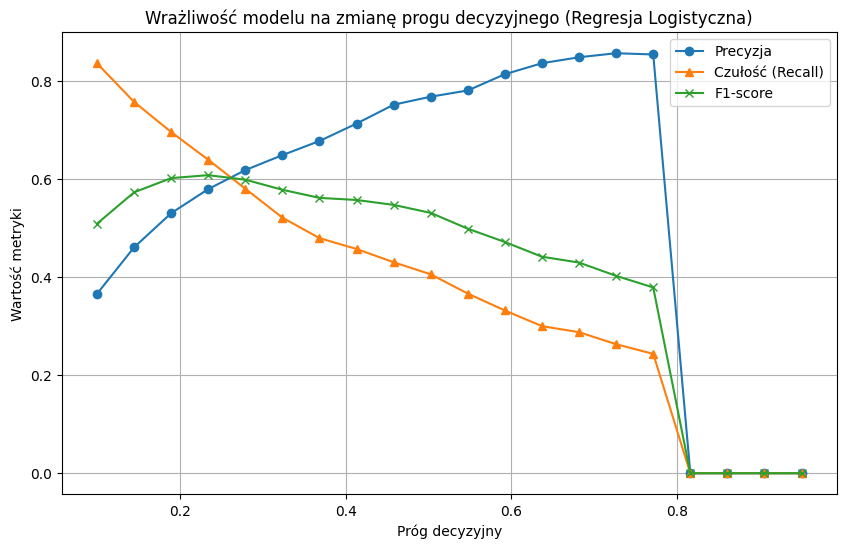

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame z wynikami progów
threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})

print("\nTabela analizy wrażliwości względem progu decyzyjnego:")
print(threshold_df.round(3))

# Wykres
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_list, marker="o", label="Precyzja")
plt.plot(thresholds, recall_list, marker="^", label="Czułość (Recall)")
plt.plot(thresholds, f1_list, marker="x", label="F1-score")

plt.xlabel("Próg decyzyjny")
plt.ylabel("Wartość metryki")
plt.title("Wrażliwość modelu na zmianę progu decyzyjnego (Regresja Logistyczna)")
plt.legend()
plt.grid(True)

plt.show()




Tabela permutacyjnej ważności cech:
             Feature  Importance
3                age       0.157
8      active_member       0.048
10   country_Germany       0.021
2             gender       0.018
5            balance       0.004
4             tenure       0.001
11     country_Spain       0.000
7        credit_card      -0.000
0        customer_id      -0.000
9   estimated_salary      -0.000
6    products_number      -0.000
1       credit_score      -0.001


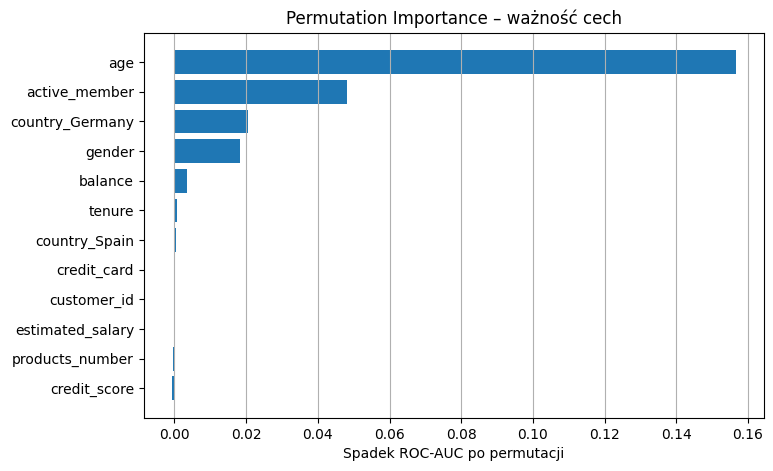

In [0]:
# ANALIZA WRAZLIWOŚCI - WAZNOŚĆ CECH 
from sklearn.inspection import permutation_importance
import numpy as np

# Permutation importance
perm_importance = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

# DataFrame z ważnościami
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTabela permutacyjnej ważności cech:")
print(feature_importance_df.round(3))

# Wykres
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Spadek ROC-AUC po permutacji")
plt.title("Permutation Importance – ważność cech")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()


In [0]:
from sklearn.metrics import roc_auc_score, classification_report

print("\nROC-AUC na zbiorze testowym:", round(roc_auc_score(y_test, y_proba), 3))
print("\nClassification report na zbiorze testowym:\n")
print(classification_report(y_test, y_pred))


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
################### PONIZEJ LAS LOSOWY #####################

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
X = df.drop(columns=["churn"])
y = df["churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



In [0]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, random_state=42)

Accuracy: 0.8565
Precision: 0.696078431372549
Recall: 0.5233415233415234
F1-score: 0.5974754558204769

Macierz pomyłek:
 [[1500   93]
 [ 194  213]]

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      1593
           1       0.70      0.52      0.60       407

    accuracy                           0.86      2000
   macro avg       0.79      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000


ROC-AUC: 0.8569092975872638


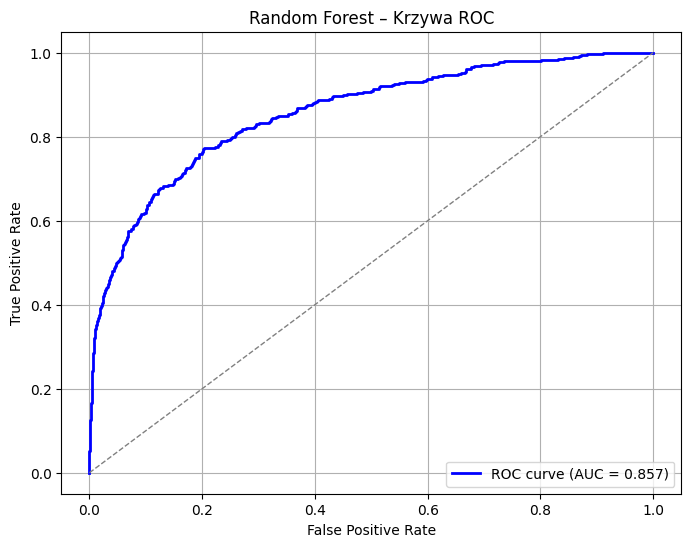

In [0]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Predykcje klasy
y_pred = rf.predict(X_test)
# Predykcje prawdopodobieństw (dla klasy 1)
y_proba = rf.predict_proba(X_test)[:, 1]

# Metryki klasyczne
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Macierz pomyłek i raport klasyfikacji
print("\nMacierz pomyłek:\n", confusion_matrix(y_test, y_pred))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC:", roc_auc)

# Krzywa ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest – Krzywa ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



In [0]:
from sklearn.metrics import roc_auc_score

y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC (Random Forest):", round(roc_auc_score(y_test, y_proba_rf), 3))


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
# ANALIZA WRAZLIWOSCI - CECHY

import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nWażność cech – Random Forest:")
print(feature_importance_df.round(3))

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Ważność cechy")
plt.title("Random Forest – Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

   Liczba drzew (n_estimators)  F1-score
0                          100  0.596639
1                          200  0.603352
2                          300  0.597475
3                          400  0.599156
4                          500  0.600281


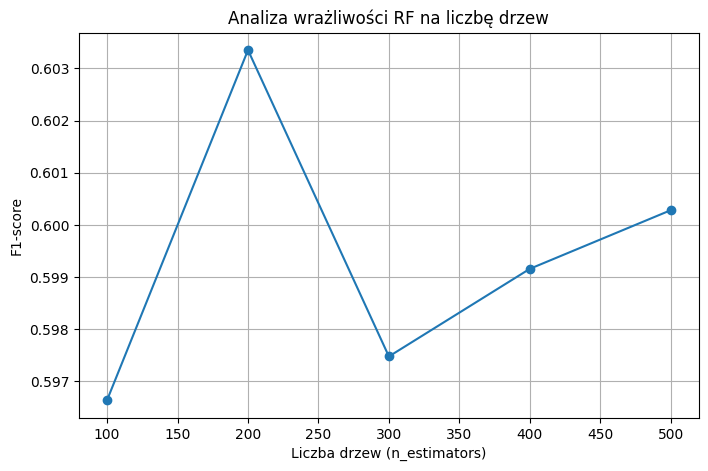

In [0]:
# ANALIZA WRAZLIWOŚCI - LICZBA DRZEW

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

n_estimators_values = [100, 200, 300, 400, 500]
f1_scores = []

for n in n_estimators_values:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    )
    
    rf_tmp.fit(X_train, y_train)
    y_pred_tmp = rf_tmp.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred_tmp))

rf_sensitivity_df = pd.DataFrame({
    "Liczba drzew (n_estimators)": n_estimators_values,
    "F1-score": f1_scores
})

print(rf_sensitivity_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    rf_sensitivity_df["Liczba drzew (n_estimators)"],
    rf_sensitivity_df["F1-score"],
    marker="o"
)

plt.xlabel("Liczba drzew (n_estimators)")
plt.ylabel("F1-score")
plt.title("Analiza wrażliwości RF na liczbę drzew")
plt.grid(True)
plt.show()


In [0]:
# ANALIZA WRAZLIWOŚCI - PRÓG DECYZYJNY

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba_rf = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    
    precision_list.append(precision_score(y_test, y_pred_t))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t))

threshold_df = pd.DataFrame({
    "Próg decyzyjny": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})

print(threshold_df.round(3))

plt.figure(figsize=(9,5))

plt.plot(threshold_df["Próg decyzyjny"], threshold_df["Precision"], label="Precyzja")
plt.plot(threshold_df["Próg decyzyjny"], threshold_df["Recall"], label="Czułość")
plt.plot(threshold_df["Próg decyzyjny"], threshold_df["F1-score"], label="F1-score", linewidth=2)

plt.xlabel("Próg decyzyjny")
plt.ylabel("Wartość metryki")
plt.title("Wpływ progu decyzyjnego na jakość klasyfikacji (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()



com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
# LAS LOSOWY - OPTYMALNY MODEL
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Definicja Random Forest z 200 drzewami
rf_opt = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

# Trenowanie modelu
rf_opt.fit(X_train, y_train)

# Predykcje prawdopodobieństw
y_proba = rf_opt.predict_proba(X_test)[:, 1]

# Predykcje klasy przy optymalnym progu 0.45
threshold = 0.45
y_pred = (y_proba >= threshold).astype(int)

# Metryki klasyczne
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Macierz pomyłek i raport klasyfikacji
print("\nMacierz pomyłek:\n", confusion_matrix(y_test, y_pred))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))

# ROC-AUC (dla pełnych prawdopodobieństw, bez progu)
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC:", roc_auc)

# Krzywa ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest – Krzywa ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
############### PONIZEJ XGBOOST ###################

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
%pip install xgboost

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
# XGBoost

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Obliczenie wagi dla klasy pozytywnej (churn=1)
# scale_pos_weight = liczba_negatywnych / liczba_pozytywnych
num_pos = sum(y_train == 1)
num_neg = sum(y_train == 0)
scale_pos_weight = num_neg / num_pos

print("scale_pos_weight =", scale_pos_weight)


xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nRaport klasyfikacji:\n")
print(classification_report(y_test, y_pred))



scale_pos_weight = 3.9079754601226995
Accuracy: 0.8105
Precision: 0.5246478873239436
Recall: 0.7321867321867321
F1-score: 0.6112820512820513
ROC-AUC: 0.8617307600358448

Raport klasyfikacji:

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1593
           1       0.52      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



Tabela analizy wrażliwości na próg decyzyjny:
    Próg decyzyjny  Precision  Recall  F1-score
0             0.10      0.252   0.975     0.400
1             0.15      0.282   0.953     0.436
2             0.20      0.314   0.924     0.469
3             0.25      0.348   0.897     0.501
4             0.30      0.375   0.860     0.522
5             0.35      0.407   0.838     0.548
6             0.40      0.445   0.801     0.572
7             0.45      0.475   0.762     0.585
8             0.50      0.525   0.732     0.611
9             0.55      0.571   0.695     0.627
10            0.60      0.604   0.651     0.626
11            0.65      0.640   0.600     0.619
12            0.70      0.687   0.565     0.620
13            0.75      0.736   0.494     0.591
14            0.80      0.816   0.435     0.567
15            0.85      0.855   0.364     0.510


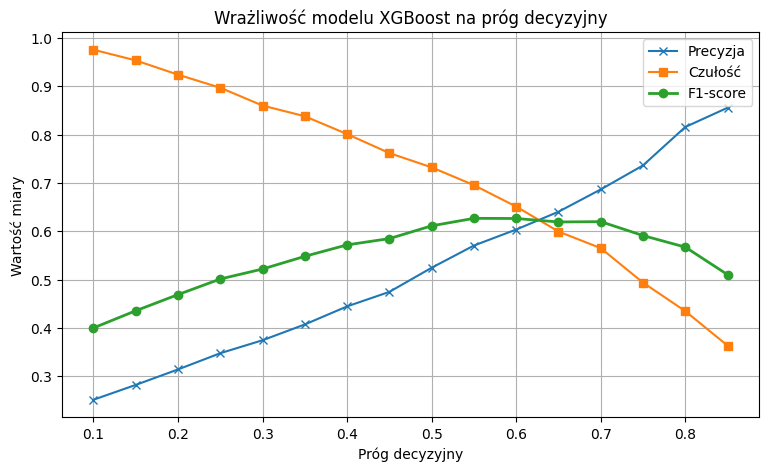

Najlepszy próg decyzyjny: 0.55 z F1-score = 0.627


In [0]:
# ANALIZA WRAZLIWOSCI - PROG DECYZYJNY


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05) 
precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_t))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t))

threshold_df = pd.DataFrame({
    "Próg decyzyjny": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})

print("Tabela analizy wrażliwości na próg decyzyjny:")
print(threshold_df.round(3))

# Wykres zmian Precyzji, Czułości i F1-score
plt.figure(figsize=(9,5))
plt.plot(thresholds, precision_list, marker='x', label='Precyzja')
plt.plot(thresholds, recall_list, marker='s', label='Czułość')
plt.plot(thresholds, f1_list, marker='o', label='F1-score', linewidth=2)

plt.xlabel("Próg decyzyjny")
plt.ylabel("Wartość miary")
plt.title("Wrażliwość modelu XGBoost na próg decyzyjny")
plt.legend()
plt.grid(True)
plt.show()

# Najlepszy próg pod kątem F1-score
best_threshold = threshold_df.loc[threshold_df["F1-score"].idxmax(), "Próg decyzyjny"]
best_f1 = threshold_df["F1-score"].max()
print(f"Najlepszy próg decyzyjny: {best_threshold:.2f} z F1-score = {best_f1:.3f}")


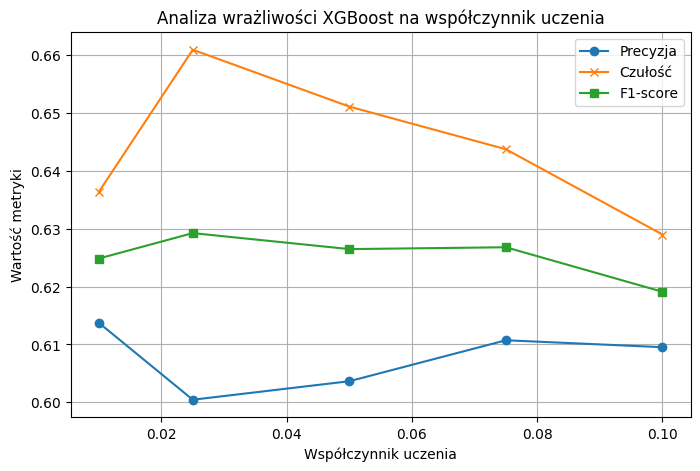

In [0]:
# ANALIZA WRAZLIWOŚCI - LEARNING RATE
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Wektor learning rates do testowania
learning_rates = [0.01, 0.025, 0.05, 0.075, 0.1]
threshold = 0.6  

precision_list = []
recall_list = []
f1_list = []

for lr in learning_rates:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Predykcje prawdopodobieństw i klasy
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Zapis metryk
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

# Wykres metryk w funkcji learning rate
plt.figure(figsize=(8,5))
plt.plot(learning_rates, precision_list, marker='o', label='Precyzja')
plt.plot(learning_rates, recall_list, marker='x', label='Czułość')
plt.plot(learning_rates, f1_list, marker='s', label='F1-score')
plt.xlabel('Współczynnik uczenia')
plt.ylabel('Wartość metryki')
plt.title('Analiza wrażliwości XGBoost na współczynnik uczenia')
plt.legend()
plt.grid(True)
plt.show()


In [0]:
# ANALIZA WRAZLIWOSCI - CECHY

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

perm_importance = permutation_importance(
    xgb_model,        
    X_test,           
    y_test,           
    n_repeats=10,     
    random_state=42,
    scoring='f1'      
)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTabela permutacyjnej ważności cech:")
print(feature_importance_df.round(3))

# Wykres słupkowy
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Spadek F1-score po permutacji cechy")
plt.ylabel("Cechy")
plt.title("XGBoost – analiza wrażliwości cech")
plt.gca().invert_yaxis()  
plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

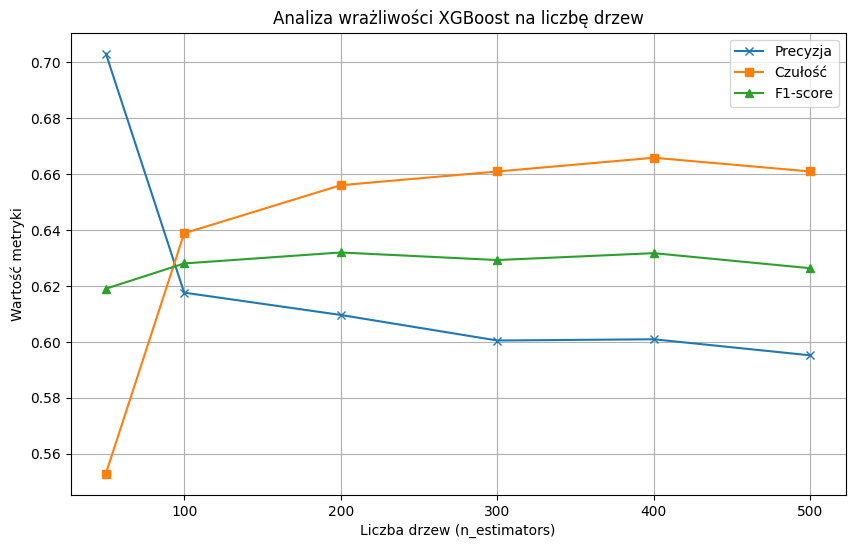

In [0]:
# ANALIZA WRAZLIWOSCI - LICZBA DRZEW
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Parametry analizy 
n_estimators_list = [50, 100, 200, 300, 400, 500]
threshold = 0.60  
learning_rate = 0.025

precision_list = []
recall_list = []
f1_list = []
accuracy_list = []

for n_tree in n_estimators_list:
    # Definicja modelu
    xgb_model = XGBClassifier(
        n_estimators=n_tree,
        max_depth=4,
        learning_rate=learning_rate,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    
    # Trenowanie
    xgb_model.fit(X_train, y_train)
    
    # Predykcja prawdopodobieństw i klasy
    y_proba = xgb_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Metryki
    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

#  Wykres wrażliwości 
plt.figure(figsize=(10,6))
plt.plot(n_estimators_list, precision_list, marker='x', label='Precyzja')
plt.plot(n_estimators_list, recall_list, marker='s', label='Czułość')
plt.plot(n_estimators_list, f1_list, marker='^', label='F1-score')

plt.xlabel('Liczba drzew (n_estimators)')
plt.ylabel('Wartość metryki')
plt.title(f'Analiza wrażliwości XGBoost na liczbę drzew')
plt.legend()
plt.grid(True)
plt.show()


In [0]:
# XGBOOST - OPTYMALNY MODEL
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

#  Finalne parametry
n_estimators_opt = 400
learning_rate_opt = 0.025
threshold_opt = 0.65

# scale_pos_weight = liczba_negatywnych / liczba_pozytywnych
num_pos = sum(y_train == 1)
num_neg = sum(y_train == 0)
scale_pos_weight = num_neg / num_pos

#  Definicja modelu 
xgb_opt = XGBClassifier(
    n_estimators=n_estimators_opt,
    max_depth=4,
    learning_rate=learning_rate_opt,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Trenowanie modelu 
xgb_opt.fit(X_train, y_train)

# Predykcje
y_proba = xgb_opt.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold_opt).astype(int)

# Metryki 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("OPTIMAL XGBoost METRICS")
print("=======================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#  Macierz pomyłek 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek – XGBoost")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.show()

# ROC curve 
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost – Krzywa ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

In [0]:
#################### PORÓWNANIE MODELI ############################

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:486)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:768)
	at com.data

Najlepsze parametry C: {'C': 100.0}
Najlepszy wynik CV ROC-AUC: 0.7663925032023192


/databricks/python/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


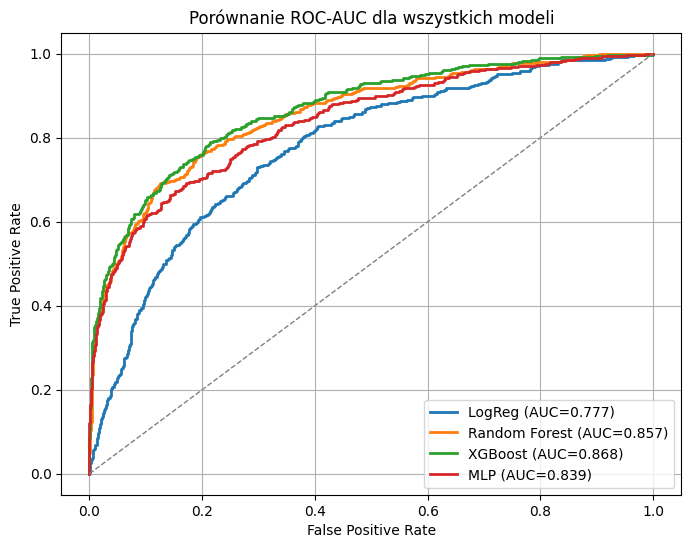

Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.776,0.45875251509054327,0.5601965601965602,0.504424778761062,0.7768184208862174
Random Forest,0.855,0.6666666666666666,0.5749385749385749,0.6174142480211082,0.8568599416057044
XGBoost,0.842,0.6008869179600886,0.6658476658476659,0.6317016317016317,0.8676349693298846
MLP,0.8555,0.6832298136645962,0.5405405405405406,0.6035665294924554,0.8386784318987708


In [0]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Przygotowanie danych 
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# GridSearchCV dla regresji logistycznej
param_grid = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}
base_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",  
    max_iter=1000
)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print("Najlepsze parametry C:", grid.best_params_)
print("Najlepszy wynik CV ROC-AUC:", grid.best_score_)

#  REGRESJA LOGISTYCZNA 
y_proba_lr = best_model.predict_proba(X_test_scaled)[:, 1]
threshold_lr = 0.6
y_pred_lr = (y_proba_lr >= threshold_lr).astype(int)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# RANDOM FOREST 
rf_opt = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_opt.fit(X_train, y_train)
y_proba_rf = rf_opt.predict_proba(X_test)[:, 1]
threshold_rf = 0.45
y_pred_rf = (y_proba_rf >= threshold_rf).astype(int)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# XGBOOST 
num_pos = sum(y_train == 1)
num_neg = sum(y_train == 0)
xgb_opt = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.025,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=num_neg/num_pos,
    random_state=42
)
xgb_opt.fit(X_train, y_train)
y_proba_xgb = xgb_opt.predict_proba(X_test)[:, 1]
threshold_xgb = 0.6
y_pred_xgb = (y_proba_xgb >= threshold_xgb).astype(int)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# MLP 
mlp_opt = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=200,
    random_state=42
)
mlp_opt.fit(X_train_scaled, y_train)
y_proba_mlp = mlp_opt.predict_proba(X_test_scaled)[:, 1]
threshold_mlp = 0.45
y_pred_mlp = (y_proba_mlp >= threshold_mlp).astype(int)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

#  ROC Curve wszystkich modeli 
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'LogReg (AUC={auc_lr:.3f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC={auc_xgb:.3f})')

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
plt.plot(fpr_mlp, tpr_mlp, lw=2, label=f'MLP (AUC={auc_mlp:.3f})')

plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Porównanie ROC-AUC dla wszystkich modeli')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#  Metryki przy optymalnym progu 
metrics = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_mlp)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_mlp)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_mlp)
    ],
    'ROC-AUC': [auc_lr, auc_rf, auc_xgb, auc_mlp]
}

metrics_df = pd.DataFrame(metrics)
display(metrics_df)
